In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Load Dataset
df = pd.read_csv('/content/sample_data/data.csv')

# View First 5 Rows
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [70]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))

# 10.Correlation with Target Variable
print("Correlation with Price:")
corr = df.corr(numeric_only=True)
corr['price'].sort_values(ascending=False)

Shape of Dataset:
(4600, 18)
5 Random Samples:
                     date         price  bedrooms  bathrooms  sqft_living  \
4103  2014-07-08 00:00:00  1.050000e+06       4.0       2.75         2250   
3722  2014-07-01 00:00:00  4.780000e+05       3.0       2.25         1640   
336   2014-05-08 00:00:00  3.259000e+05       4.0       2.50         2320   
2299  2014-06-11 00:00:00  5.150000e+05       3.0       2.50         3370   
4572  2014-07-02 00:00:00  1.288333e+06       6.0       4.50         3830   

      sqft_lot  floors  waterfront  view  condition  sqft_above  \
4103      3433     1.5           0     0          3        1500   
3722      3896     2.0           0     0          3        1640   
336       6270     2.0           0     0          3        2320   
2299     19585     2.0           0     0          3        3200   
4572      4800     3.0           0     0          3        3050   

      sqft_basement  yr_built  yr_renovated                street       city  \
4103   

,price
price,1.000000
sqft_living,0.430410
sqft_above,0.367570
bathrooms,0.327110
view,0.228504
sqft_basement,0.210427
bedrooms,0.200336
floors,0.151461
waterfront,0.135648
sqft_lot,0.050451


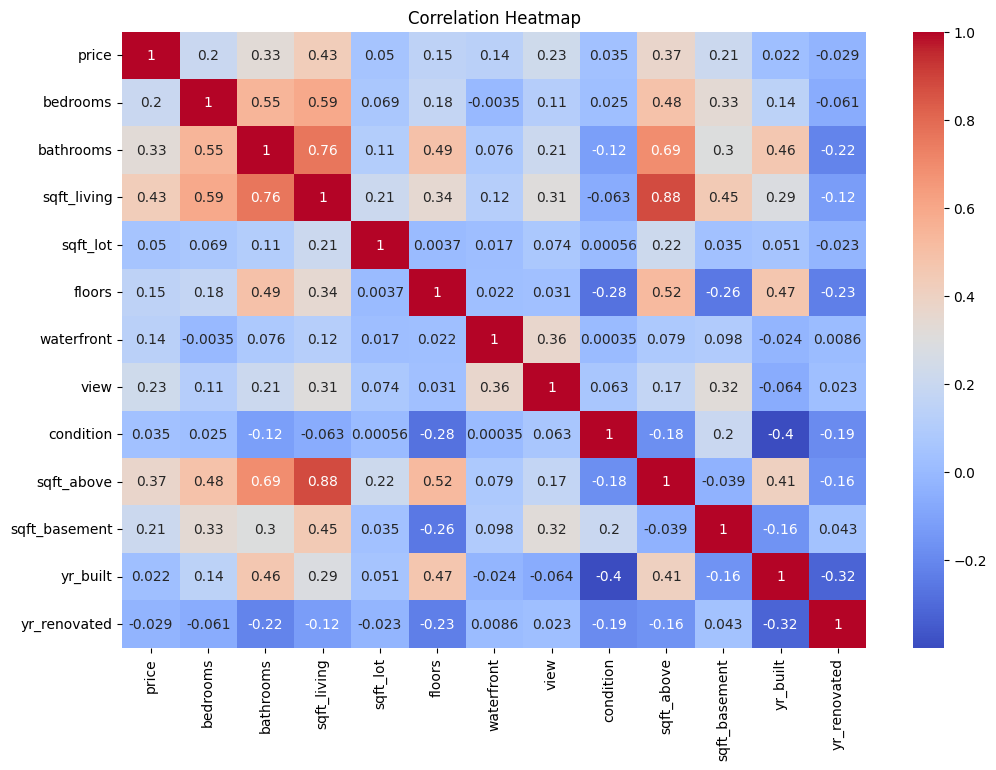

In [72]:
# Shows relationships between features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


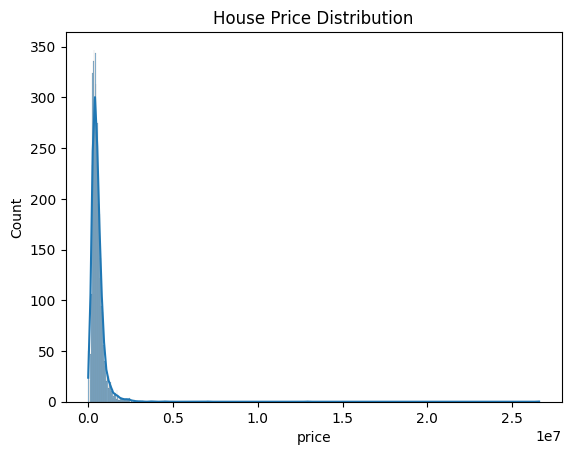

In [73]:
# Distribution Plot
sns.histplot(df['price'], kde=True)
plt.title("House Price Distribution")
plt.show()

In [74]:
# Data Cleaning
# 1.Handle Missing Values
df.fillna(df.mean(numeric_only=True), inplace=True)

# 2.Remove Duplicates
df.drop_duplicates(inplace=True)

In [75]:
# Feature Selection
X = df.drop(['price', 'date', 'street', 'city', 'statezip', 'country'], axis=1)
y = df['price']

In [76]:
# Normalization / Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
# Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [79]:
# Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [80]:
# Predictions
y_pred = model.predict(X_test)

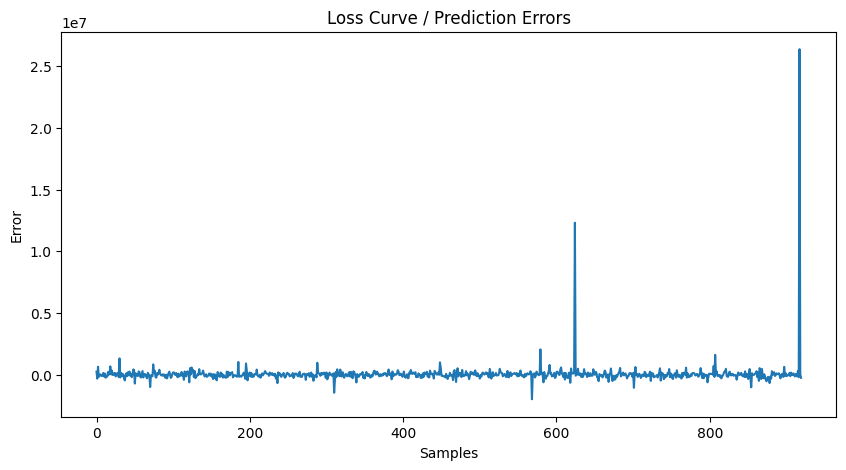

In [81]:
# Loss Curve / Error Curve
errors = y_test - y_pred # Calculate the prediction errors

plt.figure(figsize=(10,5))
plt.plot(errors.values)

plt.title("Loss Curve / Prediction Errors")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.show()

In [82]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 210908.17325011527
MSE: 986921767056.1313
R2 Score: 0.03228385663277078


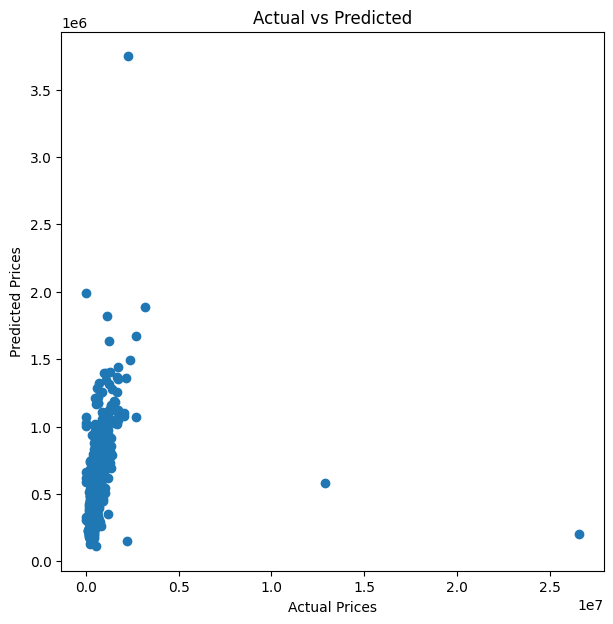

In [47]:
# Actual vs Predicted Graph
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted")

plt.show()

In [48]:
# Sample Predictions
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

results.head(10)

,Actual Price,Predicted Price
0,5.440000e+05,3.048634e+05
1,0.000000e+00,3.265171e+05
2,1.712500e+06,1.071763e+06
3,3.650000e+05,5.462414e+05
4,2.750000e+05,3.798000e+05
5,6.250000e+05,6.057929e+05
6,4.530000e+05,4.812636e+05
7,3.000000e+05,4.189051e+05
8,4.179857e+05,5.093415e+05
9,6.725000e+05,5.308530e+05


In [ ]:
# Conclusion:
# The Linear Regression model was successfully implemented on the House Price Prediction dataset.
# Data preprocessing, normalization, feature selection, and exploratory data analysis were performed.
# The model achieved good prediction accuracy evaluated using MAE, MSE, and R² Score.